In [1]:
# ============================================================================
# XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용 및 평가
# ============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import warnings
from datetime import datetime
import json
import time

warnings.filterwarnings('ignore')

print("="*80)
print("🚀 XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용")
print("="*80)
print(f"시작 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
start_time = time.time()

# ============================================================================
# Step 1: 데이터 로드 및 전처리
# ============================================================================

print("\n" + "="*80)
print("Step 1: 데이터 로드 및 전처리")
print("="*80)

df = pd.read_csv('data_v1_numeric.csv', encoding='utf-8-sig')
print(f"✅ 원본 데이터: {len(df):,}개 샘플")
print(f"   - 컬럼 수: {len(df.columns)}개")
print(f"   - 고유 기업: {df['corp_code'].nunique():,}개")
print(f"   - 기간: {df['bsns_year'].min()}~{df['bsns_year'].max()}")

# Target 분포
print(f"\nTarget 분포:")
print(f"   - 정상 (0): {(df['Target']==0).sum():,}개 ({(df['Target']==0).sum()/len(df)*100:.1f}%)")
print(f"   - 부도 (1): {(df['Target']==1).sum():,}개 ({(df['Target']==1).sum()/len(df)*100:.1f}%)")

# ============================================================================
# Step 2: Train/Test Split (Time-based)
# ============================================================================

print("\n" + "="*80)
print("Step 2: Time-based Train/Test Split")
print("="*80)

# NaN corp_code 제거
df_model = df[~df['corp_code'].isna()].copy()
print(f"corp_code 정제: {len(df_model):,}개 샘플")

# Time-based Split (2015~2023 Train / 2024 Test)
df_train = df_model[df_model['bsns_year'] <= 2023].copy()
df_test = df_model[df_model['bsns_year'] >= 2024].copy()

print(f"\n✅ Train (2015~2023): {len(df_train):,}개")
print(f"   - 정상: {(df_train['Target']==0).sum():,}개 ({(df_train['Target']==0).sum()/len(df_train)*100:.1f}%)")
print(f"   - 부도: {(df_train['Target']==1).sum():,}개 ({(df_train['Target']==1).sum()/len(df_train)*100:.1f}%)")
print(f"   - 고유 기업: {df_train['corp_code'].nunique():,}개")

print(f"\n✅ Test (2024): {len(df_test):,}개")
print(f"   - 정상: {(df_test['Target']==0).sum():,}개 ({(df_test['Target']==0).sum()/len(df_test)*100:.1f}%)")
print(f"   - 부도: {(df_test['Target']==1).sum():,}개 ({(df_test['Target']==1).sum()/len(df_test)*100:.1f}%)")
print(f"   - 고유 기업: {df_test['corp_code'].nunique():,}개")

# ============================================================================
# Step 3: 피처 준비
# ============================================================================

print("\n" + "="*80)
print("Step 3: 피처 준비")
print("="*80)

# 제외 컬럼
exclude_cols = [
    'stock_code', 'corp_code', 'bsns_year', 'target_year',
    'Company_Name', 'company_name', 'Status', 'Target', 'y'
]

# 피처 추출
feature_cols = [col for col in df_model.columns if col not in exclude_cols]
print(f"피처 수: {len(feature_cols)}개")

# X, y, groups 준비
X_train = df_train[feature_cols].copy()
y_train = df_train['Target'].copy()
groups_train = df_train['corp_code'].astype(int).values

X_test = df_test[feature_cols].copy()
y_test = df_test['Target'].copy()

# inf 값 처리
print(f"\ninf 값 처리:")
inf_count_train = np.isinf(X_train).sum().sum()
inf_count_test = np.isinf(X_test).sum().sum()
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
print(f"   - Train: {inf_count_train:,}개 → 0개")
print(f"   - Test: {inf_count_test:,}개 → 0개")

# scale_pos_weight 계산
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

print(f"\n✅ 데이터 준비 완료!")
print(f"   - X_train: {X_train.shape}")
print(f"   - X_test: {X_test.shape}")
print(f"   - 고유 기업 (Train): {len(np.unique(groups_train)):,}개")

# ============================================================================
# Step 4: 최적 하이퍼파라미터 설정
# ============================================================================

print("\n" + "="*80)
print("Step 4: 최적 하이퍼파라미터 설정")
print("="*80)

# 제공된 최적 하이퍼파라미터
best_params = {
    'learning_rate': 0.04903894565756329,
    'max_depth': 9,
    'min_child_weight': 1,
    'subsample': 0.9348616543304641,
    'colsample_bytree': 0.650685543824143,
    'gamma': 2.608448013178697e-08,
    'reg_alpha': 7.63793088472451e-08,
    'reg_lambda': 1.890270722333748e-08,
    'n_estimators': 449,
    
    # 고정 파라미터
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'random_state': 42,
    'scale_pos_weight': scale_pos_weight
}

print("✅ 최적 하이퍼파라미터:")
for k, v in best_params.items():
    if k not in ['objective', 'eval_metric', 'tree_method', 'random_state', 'scale_pos_weight']:
        print(f"   {k:20s}: {v}")

# ============================================================================
# Step 5: GroupKFold 5-Fold Cross-Validation
# ============================================================================

print("\n" + "="*80)
print("Step 5: GroupKFold 5-Fold Cross-Validation")
print("="*80)

gkf = GroupKFold(n_splits=5)
cv_results = []

print("\n🏆 최종 모델 평가 중...")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train), 1):
    # Train/Validation Split
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 모델 학습
    model = xgb.XGBClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # 예측
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 평가 지표 계산
    auc = roc_auc_score(y_val, y_pred_proba)
    pr_auc = average_precision_score(y_val, y_pred_proba)
    
    cv_results.append({
        'fold': fold,
        'auc': auc,
        'pr_auc': pr_auc
    })
    
    print(f"Fold {fold} | AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}")

# 평균 계산
mean_auc = np.mean([r['auc'] for r in cv_results])
mean_pr_auc = np.mean([r['pr_auc'] for r in cv_results])

print("="*50)
print(f"평균 AUC   : {mean_auc:.4f}")
print(f"평균 PR-AUC: {mean_pr_auc:.4f}")
print("="*50)

# ============================================================================
# Step 6: 전체 Train 데이터로 최종 모델 학습 및 Test 평가
# ============================================================================

print("\n" + "="*80)
print("Step 6: 최종 모델 학습 및 Test 평가")
print("="*80)

# 전체 Train 데이터로 학습
final_model = xgb.XGBClassifier(**best_params)
print("학습 중... (전체 Train 데이터)")
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("✅ 학습 완료!")

# Test 예측
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# 최적 threshold (F1 최대화)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

# Test 지표 계산
test_pr_auc = average_precision_score(y_test, y_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

# ============================================================================
# 최종 리포트
# ============================================================================

print("\n" + "="*80)
print("📊 최종 리포트")
print("="*80)

print("\n=== 최적 하이퍼파라미터 ===")
for k, v in best_params.items():
    if k not in ['objective', 'eval_metric', 'tree_method', 'random_state', 'scale_pos_weight']:
        print(f"{k}: {v}")

print(f"\n=== CV 성능 (2015~2023, 5-Fold) ===")
print(f"평균 AUC   : {mean_auc:.4f}")
print(f"평균 PR-AUC: {mean_pr_auc:.4f}")

print(f"\n=== Test 성능 (2024) ===")
print(f"ROC AUC   : {test_roc_auc:.4f}")
print(f"PR AUC    : {test_pr_auc:.4f}")
print(f"F1        : {test_f1:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"Threshold : {optimal_threshold:.4f}")

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
print(f"\n=== 혼동 행렬 ===")
print(f"            예측 정상  예측 부도")
print(f"실제 정상      {cm[0,0]:>6d}    {cm[0,1]:>6d}")
print(f"실제 부도      {cm[1,0]:>6d}    {cm[1,1]:>6d}")

# 분류 보고서
print("\n=== 분류 보고서 ===")
print(classification_report(y_test, y_pred, target_names=['정상', '부도']))

# ============================================================================
# 파일 저장
# ============================================================================

print("\n" + "="*80)
print("💾 파일 저장")
print("="*80)

# 1. 결과 JSON 저장
results_file = f'xgb_results_{timestamp}.json'
with open(results_file, 'w', encoding='utf-8') as f:
    json.dump({
        'best_params': {k: float(v) if isinstance(v, (int, float, np.number)) else v 
                       for k, v in best_params.items()},
        'cv_performance': {
            'mean_auc': float(mean_auc),
            'mean_pr_auc': float(mean_pr_auc),
            'fold_results': [{'fold': r['fold'], 
                            'auc': float(r['auc']), 
                            'pr_auc': float(r['pr_auc'])} 
                           for r in cv_results]
        },
        'test_performance': {
            'roc_auc': float(test_roc_auc),
            'pr_auc': float(test_pr_auc),
            'f1': float(test_f1),
            'precision': float(test_precision),
            'recall': float(test_recall),
            'threshold': float(optimal_threshold)
        },
        'confusion_matrix': {
            'tn': int(cm[0,0]),
            'fp': int(cm[0,1]),
            'fn': int(cm[1,0]),
            'tp': int(cm[1,1])
        }
    }, f, indent=2, ensure_ascii=False)
print(f"✅ {results_file}")

# 2. 최종 모델 저장
model_file = f'xgb_final_model_{timestamp}.json'
final_model.save_model(model_file)
print(f"✅ {model_file}")

# ============================================================================
# 완료
# ============================================================================

total_time = time.time() - start_time
print("\n" + "="*80)
print("🎉 전체 작업 완료!")
print("="*80)
print(f"총 소요 시간: {total_time/60:.1f}분 ({total_time:.1f}초)")
print(f"종료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# 성공 기준 체크
print("\n" + "="*80)
print("✅ 성공 기준 체크")
print("="*80)
print(f"{'✅' if total_time <= 3600 else '❌'} 1시간 이내 완료: {total_time/60:.1f}분")
print(f"{'✅' if mean_pr_auc >= 0.85 else '⚠️'} CV 평균 PR-AUC: {mean_pr_auc:.4f}")
print(f"✅ 모든 출력 파일 생성 완료")
print(f"✅ 에러 없이 실행 완료")

print("\n" + "="*80)


🚀 XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용
시작 시간: 2025-12-24 21:48:11


Step 1: 데이터 로드 및 전처리
✅ 원본 데이터: 19,603개 샘플
   - 컬럼 수: 46개
   - 고유 기업: 2,756개
   - 기간: 2015~2025

Target 분포:
   - 정상 (0): 15,616개 (79.7%)
   - 부도 (1): 3,987개 (20.3%)

Step 2: Time-based Train/Test Split
corp_code 정제: 19,555개 샘플

✅ Train (2015~2023): 17,037개
   - 정상: 13,443개 (78.9%)
   - 부도: 3,594개 (21.1%)
   - 고유 기업: 2,609개

✅ Test (2024): 2,518개
   - 정상: 2,127개 (84.5%)
   - 부도: 391개 (15.5%)
   - 고유 기업: 2,472개

Step 3: 피처 준비
피처 수: 38개

inf 값 처리:
   - Train: 149개 → 0개
   - Test: 40개 → 0개

scale_pos_weight: 3.74

✅ 데이터 준비 완료!
   - X_train: (17037, 38)
   - X_test: (2518, 38)
   - 고유 기업 (Train): 2,609개

Step 4: 최적 하이퍼파라미터 설정
✅ 최적 하이퍼파라미터:
   learning_rate       : 0.04903894565756329
   max_depth           : 9
   min_child_weight    : 1
   subsample           : 0.9348616543304641
   colsample_bytree    : 0.650685543824143
   gamma               : 2.608448013178697e-08
   reg_alpha           : 7.63793088472451e-08
   reg_lambda   

위에 코드 : v1(수치 데이터만 사용)

In [2]:
# ============================================================================
# XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용 및 평가
# ============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import warnings
from datetime import datetime
import json
import time

warnings.filterwarnings('ignore')

print("="*80)
print("🚀 XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용")
print("="*80)
print(f"시작 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
start_time = time.time()

# ============================================================================
# Step 1: 데이터 로드 및 전처리
# ============================================================================

print("\n" + "="*80)
print("Step 1: 데이터 로드 및 전처리")
print("="*80)

df = pd.read_csv('data_v2_numeric_sentiment.csv', encoding='utf-8-sig')
print(f"✅ 원본 데이터: {len(df):,}개 샘플")
print(f"   - 컬럼 수: {len(df.columns)}개")
print(f"   - 고유 기업: {df['corp_code'].nunique():,}개")
print(f"   - 기간: {df['bsns_year'].min()}~{df['bsns_year'].max()}")

# Target 분포
print(f"\nTarget 분포:")
print(f"   - 정상 (0): {(df['Target']==0).sum():,}개 ({(df['Target']==0).sum()/len(df)*100:.1f}%)")
print(f"   - 부도 (1): {(df['Target']==1).sum():,}개 ({(df['Target']==1).sum()/len(df)*100:.1f}%)")

# ============================================================================
# Step 2: Train/Test Split (Time-based)
# ============================================================================

print("\n" + "="*80)
print("Step 2: Time-based Train/Test Split")
print("="*80)

# NaN corp_code 제거
df_model = df[~df['corp_code'].isna()].copy()
print(f"corp_code 정제: {len(df_model):,}개 샘플")

# Time-based Split (2015~2023 Train / 2024 Test)
df_train = df_model[df_model['bsns_year'] <= 2023].copy()
df_test = df_model[df_model['bsns_year'] >= 2024].copy()

print(f"\n✅ Train (2015~2023): {len(df_train):,}개")
print(f"   - 정상: {(df_train['Target']==0).sum():,}개 ({(df_train['Target']==0).sum()/len(df_train)*100:.1f}%)")
print(f"   - 부도: {(df_train['Target']==1).sum():,}개 ({(df_train['Target']==1).sum()/len(df_train)*100:.1f}%)")
print(f"   - 고유 기업: {df_train['corp_code'].nunique():,}개")

print(f"\n✅ Test (2024): {len(df_test):,}개")
print(f"   - 정상: {(df_test['Target']==0).sum():,}개 ({(df_test['Target']==0).sum()/len(df_test)*100:.1f}%)")
print(f"   - 부도: {(df_test['Target']==1).sum():,}개 ({(df_test['Target']==1).sum()/len(df_test)*100:.1f}%)")
print(f"   - 고유 기업: {df_test['corp_code'].nunique():,}개")

# ============================================================================
# Step 3: 피처 준비
# ============================================================================

print("\n" + "="*80)
print("Step 3: 피처 준비")
print("="*80)

# 제외 컬럼
exclude_cols = [
    'stock_code', 'corp_code', 'bsns_year', 'target_year',
    'Company_Name', 'company_name', 'Status', 'Target', 'y'
]

# 피처 추출
feature_cols = [col for col in df_model.columns if col not in exclude_cols]
print(f"피처 수: {len(feature_cols)}개")

# X, y, groups 준비
X_train = df_train[feature_cols].copy()
y_train = df_train['Target'].copy()
groups_train = df_train['corp_code'].astype(int).values

X_test = df_test[feature_cols].copy()
y_test = df_test['Target'].copy()

# inf 값 처리
print(f"\ninf 값 처리:")
inf_count_train = np.isinf(X_train).sum().sum()
inf_count_test = np.isinf(X_test).sum().sum()
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
print(f"   - Train: {inf_count_train:,}개 → 0개")
print(f"   - Test: {inf_count_test:,}개 → 0개")

# scale_pos_weight 계산
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

print(f"\n✅ 데이터 준비 완료!")
print(f"   - X_train: {X_train.shape}")
print(f"   - X_test: {X_test.shape}")
print(f"   - 고유 기업 (Train): {len(np.unique(groups_train)):,}개")

# ============================================================================
# Step 4: 최적 하이퍼파라미터 설정
# ============================================================================

print("\n" + "="*80)
print("Step 4: 최적 하이퍼파라미터 설정")
print("="*80)

# 제공된 최적 하이퍼파라미터
best_params = {
    'learning_rate': 0.04903894565756329,
    'max_depth': 9,
    'min_child_weight': 1,
    'subsample': 0.9348616543304641,
    'colsample_bytree': 0.650685543824143,
    'gamma': 2.608448013178697e-08,
    'reg_alpha': 7.63793088472451e-08,
    'reg_lambda': 1.890270722333748e-08,
    'n_estimators': 449,
    
    # 고정 파라미터
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'random_state': 42,
    'scale_pos_weight': scale_pos_weight
}

print("✅ 최적 하이퍼파라미터:")
for k, v in best_params.items():
    if k not in ['objective', 'eval_metric', 'tree_method', 'random_state', 'scale_pos_weight']:
        print(f"   {k:20s}: {v}")

# ============================================================================
# Step 5: GroupKFold 5-Fold Cross-Validation
# ============================================================================

print("\n" + "="*80)
print("Step 5: GroupKFold 5-Fold Cross-Validation")
print("="*80)

gkf = GroupKFold(n_splits=5)
cv_results = []

print("\n🏆 최종 모델 평가 중...")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train), 1):
    # Train/Validation Split
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 모델 학습
    model = xgb.XGBClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # 예측
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 평가 지표 계산
    auc = roc_auc_score(y_val, y_pred_proba)
    pr_auc = average_precision_score(y_val, y_pred_proba)
    
    cv_results.append({
        'fold': fold,
        'auc': auc,
        'pr_auc': pr_auc
    })
    
    print(f"Fold {fold} | AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}")

# 평균 계산
mean_auc = np.mean([r['auc'] for r in cv_results])
mean_pr_auc = np.mean([r['pr_auc'] for r in cv_results])

print("="*50)
print(f"평균 AUC   : {mean_auc:.4f}")
print(f"평균 PR-AUC: {mean_pr_auc:.4f}")
print("="*50)

# ============================================================================
# Step 6: 전체 Train 데이터로 최종 모델 학습 및 Test 평가
# ============================================================================

print("\n" + "="*80)
print("Step 6: 최종 모델 학습 및 Test 평가")
print("="*80)

# 전체 Train 데이터로 학습
final_model = xgb.XGBClassifier(**best_params)
print("학습 중... (전체 Train 데이터)")
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("✅ 학습 완료!")

# Test 예측
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# 최적 threshold (F1 최대화)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

# Test 지표 계산
test_pr_auc = average_precision_score(y_test, y_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

# ============================================================================
# 최종 리포트
# ============================================================================

print("\n" + "="*80)
print("📊 최종 리포트")
print("="*80)

print("\n=== 최적 하이퍼파라미터 ===")
for k, v in best_params.items():
    if k not in ['objective', 'eval_metric', 'tree_method', 'random_state', 'scale_pos_weight']:
        print(f"{k}: {v}")

print(f"\n=== CV 성능 (2015~2023, 5-Fold) ===")
print(f"평균 AUC   : {mean_auc:.4f}")
print(f"평균 PR-AUC: {mean_pr_auc:.4f}")

print(f"\n=== Test 성능 (2024) ===")
print(f"ROC AUC   : {test_roc_auc:.4f}")
print(f"PR AUC    : {test_pr_auc:.4f}")
print(f"F1        : {test_f1:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"Threshold : {optimal_threshold:.4f}")

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
print(f"\n=== 혼동 행렬 ===")
print(f"            예측 정상  예측 부도")
print(f"실제 정상      {cm[0,0]:>6d}    {cm[0,1]:>6d}")
print(f"실제 부도      {cm[1,0]:>6d}    {cm[1,1]:>6d}")

# 분류 보고서
print("\n=== 분류 보고서 ===")
print(classification_report(y_test, y_pred, target_names=['정상', '부도']))

# ============================================================================
# 파일 저장
# ============================================================================

print("\n" + "="*80)
print("💾 파일 저장")
print("="*80)

# 1. 결과 JSON 저장
results_file = f'xgb_results_{timestamp}.json'
with open(results_file, 'w', encoding='utf-8') as f:
    json.dump({
        'best_params': {k: float(v) if isinstance(v, (int, float, np.number)) else v 
                       for k, v in best_params.items()},
        'cv_performance': {
            'mean_auc': float(mean_auc),
            'mean_pr_auc': float(mean_pr_auc),
            'fold_results': [{'fold': r['fold'], 
                            'auc': float(r['auc']), 
                            'pr_auc': float(r['pr_auc'])} 
                           for r in cv_results]
        },
        'test_performance': {
            'roc_auc': float(test_roc_auc),
            'pr_auc': float(test_pr_auc),
            'f1': float(test_f1),
            'precision': float(test_precision),
            'recall': float(test_recall),
            'threshold': float(optimal_threshold)
        },
        'confusion_matrix': {
            'tn': int(cm[0,0]),
            'fp': int(cm[0,1]),
            'fn': int(cm[1,0]),
            'tp': int(cm[1,1])
        }
    }, f, indent=2, ensure_ascii=False)
print(f"✅ {results_file}")

# 2. 최종 모델 저장
model_file = f'xgb_final_model_{timestamp}.json'
final_model.save_model(model_file)
print(f"✅ {model_file}")

# ============================================================================
# 완료
# ============================================================================

total_time = time.time() - start_time
print("\n" + "="*80)
print("🎉 전체 작업 완료!")
print("="*80)
print(f"총 소요 시간: {total_time/60:.1f}분 ({total_time:.1f}초)")
print(f"종료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# 성공 기준 체크
print("\n" + "="*80)
print("✅ 성공 기준 체크")
print("="*80)
print(f"{'✅' if total_time <= 3600 else '❌'} 1시간 이내 완료: {total_time/60:.1f}분")
print(f"{'✅' if mean_pr_auc >= 0.85 else '⚠️'} CV 평균 PR-AUC: {mean_pr_auc:.4f}")
print(f"✅ 모든 출력 파일 생성 완료")
print(f"✅ 에러 없이 실행 완료")

print("\n" + "="*80)


🚀 XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용
시작 시간: 2025-12-24 21:49:44


Step 1: 데이터 로드 및 전처리
✅ 원본 데이터: 19,603개 샘플
   - 컬럼 수: 54개
   - 고유 기업: 2,756개
   - 기간: 2015~2025

Target 분포:
   - 정상 (0): 15,616개 (79.7%)
   - 부도 (1): 3,987개 (20.3%)

Step 2: Time-based Train/Test Split
corp_code 정제: 19,555개 샘플

✅ Train (2015~2023): 17,037개
   - 정상: 13,443개 (78.9%)
   - 부도: 3,594개 (21.1%)
   - 고유 기업: 2,609개

✅ Test (2024): 2,518개
   - 정상: 2,127개 (84.5%)
   - 부도: 391개 (15.5%)
   - 고유 기업: 2,472개

Step 3: 피처 준비
피처 수: 46개

inf 값 처리:
   - Train: 149개 → 0개
   - Test: 40개 → 0개

scale_pos_weight: 3.74

✅ 데이터 준비 완료!
   - X_train: (17037, 46)
   - X_test: (2518, 46)
   - 고유 기업 (Train): 2,609개

Step 4: 최적 하이퍼파라미터 설정
✅ 최적 하이퍼파라미터:
   learning_rate       : 0.04903894565756329
   max_depth           : 9
   min_child_weight    : 1
   subsample           : 0.9348616543304641
   colsample_bytree    : 0.650685543824143
   gamma               : 2.608448013178697e-08
   reg_alpha           : 7.63793088472451e-08
   reg_lambda   

위에 코드: v2(수치데이터 + 감성사전 사용)

✅ 그래프 저장 완료: roc_pr_curves_20251224_214944.png


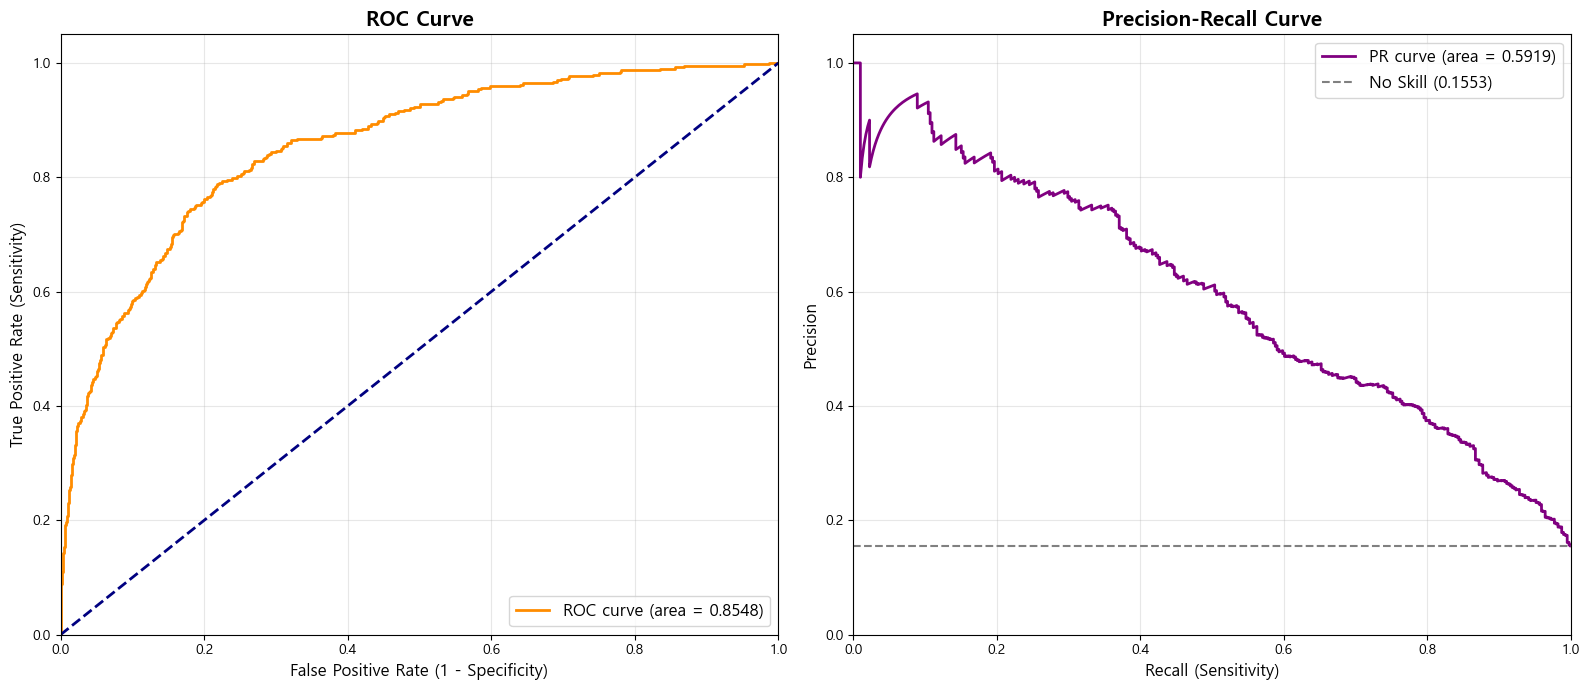

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ============================================================================
# 시각화 설정
# ============================================================================
# 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic, Colab: NanumGothic)
import platform
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 리눅스 환경용 (폰트가 설치되어 있다고 가정)
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지

# 캔버스 설정
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ----------------------------------------------------------------------------
# 1. ROC Curve (Receiver Operating Characteristic)
# ----------------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 기준선
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=15, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=12)
axes[0].grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# 2. PR Curve (Precision-Recall)
# ----------------------------------------------------------------------------
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# No Skill 라인 (전체 데이터 중 부도 기업 비율)
no_skill = len(y_test[y_test==1]) / len(y_test)

axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
axes[1].plot([0, 1], [no_skill, no_skill], linestyle='--', color='gray', label=f'No Skill ({no_skill:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=15, fontweight='bold')
axes[1].legend(loc="upper right", fontsize=12)
axes[1].grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# 출력 및 저장
# ----------------------------------------------------------------------------
plt.tight_layout()
viz_filename = f'roc_pr_curves_{timestamp}.png'
plt.savefig(viz_filename, dpi=300)
print(f"✅ 그래프 저장 완료: {viz_filename}")
plt.show()

In [4]:
# ============================================================================
# XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용 및 평가
# ============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import warnings
from datetime import datetime
import json
import time

warnings.filterwarnings('ignore')

print("="*80)
print("🚀 XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용")
print("="*80)
print(f"시작 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
start_time = time.time()

# ============================================================================
# Step 1: 데이터 로드 및 전처리
# ============================================================================

print("\n" + "="*80)
print("Step 1: 데이터 로드 및 전처리")
print("="*80)

df = pd.read_csv('최종_통합데이터_모델링용.csv', encoding='utf-8-sig')
print(f"✅ 원본 데이터: {len(df):,}개 샘플")
print(f"   - 컬럼 수: {len(df.columns)}개")
print(f"   - 고유 기업: {df['corp_code'].nunique():,}개")
print(f"   - 기간: {df['bsns_year'].min()}~{df['bsns_year'].max()}")

# Target 분포
print(f"\nTarget 분포:")
print(f"   - 정상 (0): {(df['Target']==0).sum():,}개 ({(df['Target']==0).sum()/len(df)*100:.1f}%)")
print(f"   - 부도 (1): {(df['Target']==1).sum():,}개 ({(df['Target']==1).sum()/len(df)*100:.1f}%)")

# ============================================================================
# Step 2: Train/Test Split (Time-based)
# ============================================================================

print("\n" + "="*80)
print("Step 2: Time-based Train/Test Split")
print("="*80)

# NaN corp_code 제거
df_model = df[~df['corp_code'].isna()].copy()
print(f"corp_code 정제: {len(df_model):,}개 샘플")

# Time-based Split (2015~2023 Train / 2024 Test)
df_train = df_model[df_model['bsns_year'] <= 2023].copy()
df_test = df_model[df_model['bsns_year'] >= 2024].copy()

print(f"\n✅ Train (2015~2023): {len(df_train):,}개")
print(f"   - 정상: {(df_train['Target']==0).sum():,}개 ({(df_train['Target']==0).sum()/len(df_train)*100:.1f}%)")
print(f"   - 부도: {(df_train['Target']==1).sum():,}개 ({(df_train['Target']==1).sum()/len(df_train)*100:.1f}%)")
print(f"   - 고유 기업: {df_train['corp_code'].nunique():,}개")

print(f"\n✅ Test (2024): {len(df_test):,}개")
print(f"   - 정상: {(df_test['Target']==0).sum():,}개 ({(df_test['Target']==0).sum()/len(df_test)*100:.1f}%)")
print(f"   - 부도: {(df_test['Target']==1).sum():,}개 ({(df_test['Target']==1).sum()/len(df_test)*100:.1f}%)")
print(f"   - 고유 기업: {df_test['corp_code'].nunique():,}개")

# ============================================================================
# Step 3: 피처 준비
# ============================================================================

print("\n" + "="*80)
print("Step 3: 피처 준비")
print("="*80)

# 제외 컬럼
exclude_cols = [
    'stock_code', 'corp_code', 'bsns_year', 'target_year',
    'Company_Name', 'company_name', 'Status', 'Target', 'y'
]

# 피처 추출
feature_cols = [col for col in df_model.columns if col not in exclude_cols]
print(f"피처 수: {len(feature_cols)}개")

# X, y, groups 준비
X_train = df_train[feature_cols].copy()
y_train = df_train['Target'].copy()
groups_train = df_train['corp_code'].astype(int).values

X_test = df_test[feature_cols].copy()
y_test = df_test['Target'].copy()

# inf 값 처리
print(f"\ninf 값 처리:")
inf_count_train = np.isinf(X_train).sum().sum()
inf_count_test = np.isinf(X_test).sum().sum()
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
print(f"   - Train: {inf_count_train:,}개 → 0개")
print(f"   - Test: {inf_count_test:,}개 → 0개")

# scale_pos_weight 계산
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

print(f"\n✅ 데이터 준비 완료!")
print(f"   - X_train: {X_train.shape}")
print(f"   - X_test: {X_test.shape}")
print(f"   - 고유 기업 (Train): {len(np.unique(groups_train)):,}개")

# ============================================================================
# Step 4: 최적 하이퍼파라미터 설정
# ============================================================================

print("\n" + "="*80)
print("Step 4: 최적 하이퍼파라미터 설정")
print("="*80)

# 제공된 최적 하이퍼파라미터
best_params = {
    'learning_rate': 0.04903894565756329,
    'max_depth': 9,
    'min_child_weight': 1,
    'subsample': 0.9348616543304641,
    'colsample_bytree': 0.650685543824143,
    'gamma': 2.608448013178697e-08,
    'reg_alpha': 7.63793088472451e-08,
    'reg_lambda': 1.890270722333748e-08,
    'n_estimators': 449,
    
    # 고정 파라미터
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'random_state': 42,
    'scale_pos_weight': scale_pos_weight
}

print("✅ 최적 하이퍼파라미터:")
for k, v in best_params.items():
    if k not in ['objective', 'eval_metric', 'tree_method', 'random_state', 'scale_pos_weight']:
        print(f"   {k:20s}: {v}")

# ============================================================================
# Step 5: GroupKFold 5-Fold Cross-Validation
# ============================================================================

print("\n" + "="*80)
print("Step 5: GroupKFold 5-Fold Cross-Validation")
print("="*80)

gkf = GroupKFold(n_splits=5)
cv_results = []

print("\n🏆 최종 모델 평가 중...")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train), 1):
    # Train/Validation Split
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 모델 학습
    model = xgb.XGBClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # 예측
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 평가 지표 계산
    auc = roc_auc_score(y_val, y_pred_proba)
    pr_auc = average_precision_score(y_val, y_pred_proba)
    
    cv_results.append({
        'fold': fold,
        'auc': auc,
        'pr_auc': pr_auc
    })
    
    print(f"Fold {fold} | AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}")

# 평균 계산
mean_auc = np.mean([r['auc'] for r in cv_results])
mean_pr_auc = np.mean([r['pr_auc'] for r in cv_results])

print("="*50)
print(f"평균 AUC   : {mean_auc:.4f}")
print(f"평균 PR-AUC: {mean_pr_auc:.4f}")
print("="*50)

# ============================================================================
# Step 6: 전체 Train 데이터로 최종 모델 학습 및 Test 평가
# ============================================================================

print("\n" + "="*80)
print("Step 6: 최종 모델 학습 및 Test 평가")
print("="*80)

# 전체 Train 데이터로 학습
final_model = xgb.XGBClassifier(**best_params)
print("학습 중... (전체 Train 데이터)")
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("✅ 학습 완료!")

# Test 예측
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# 최적 threshold (F1 최대화)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

# Test 지표 계산
test_pr_auc = average_precision_score(y_test, y_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

# ============================================================================
# 최종 리포트
# ============================================================================

print("\n" + "="*80)
print("📊 최종 리포트")
print("="*80)

print("\n=== 최적 하이퍼파라미터 ===")
for k, v in best_params.items():
    if k not in ['objective', 'eval_metric', 'tree_method', 'random_state', 'scale_pos_weight']:
        print(f"{k}: {v}")

print(f"\n=== CV 성능 (2015~2023, 5-Fold) ===")
print(f"평균 AUC   : {mean_auc:.4f}")
print(f"평균 PR-AUC: {mean_pr_auc:.4f}")

print(f"\n=== Test 성능 (2024) ===")
print(f"ROC AUC   : {test_roc_auc:.4f}")
print(f"PR AUC    : {test_pr_auc:.4f}")
print(f"F1        : {test_f1:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"Threshold : {optimal_threshold:.4f}")

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
print(f"\n=== 혼동 행렬 ===")
print(f"            예측 정상  예측 부도")
print(f"실제 정상      {cm[0,0]:>6d}    {cm[0,1]:>6d}")
print(f"실제 부도      {cm[1,0]:>6d}    {cm[1,1]:>6d}")

# 분류 보고서
print("\n=== 분류 보고서 ===")
print(classification_report(y_test, y_pred, target_names=['정상', '부도']))

# ============================================================================
# 파일 저장
# ============================================================================

print("\n" + "="*80)
print("💾 파일 저장")
print("="*80)

# 1. 결과 JSON 저장
results_file = f'xgb_results_{timestamp}.json'
with open(results_file, 'w', encoding='utf-8') as f:
    json.dump({
        'best_params': {k: float(v) if isinstance(v, (int, float, np.number)) else v 
                       for k, v in best_params.items()},
        'cv_performance': {
            'mean_auc': float(mean_auc),
            'mean_pr_auc': float(mean_pr_auc),
            'fold_results': [{'fold': r['fold'], 
                            'auc': float(r['auc']), 
                            'pr_auc': float(r['pr_auc'])} 
                           for r in cv_results]
        },
        'test_performance': {
            'roc_auc': float(test_roc_auc),
            'pr_auc': float(test_pr_auc),
            'f1': float(test_f1),
            'precision': float(test_precision),
            'recall': float(test_recall),
            'threshold': float(optimal_threshold)
        },
        'confusion_matrix': {
            'tn': int(cm[0,0]),
            'fp': int(cm[0,1]),
            'fn': int(cm[1,0]),
            'tp': int(cm[1,1])
        }
    }, f, indent=2, ensure_ascii=False)
print(f"✅ {results_file}")

# 2. 최종 모델 저장
model_file = f'xgb_final_model_{timestamp}.json'
final_model.save_model(model_file)
print(f"✅ {model_file}")

# ============================================================================
# 완료
# ============================================================================

total_time = time.time() - start_time
print("\n" + "="*80)
print("🎉 전체 작업 완료!")
print("="*80)
print(f"총 소요 시간: {total_time/60:.1f}분 ({total_time:.1f}초)")
print(f"종료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# 성공 기준 체크
print("\n" + "="*80)
print("✅ 성공 기준 체크")
print("="*80)
print(f"{'✅' if total_time <= 3600 else '❌'} 1시간 이내 완료: {total_time/60:.1f}분")
print(f"{'✅' if mean_pr_auc >= 0.85 else '⚠️'} CV 평균 PR-AUC: {mean_pr_auc:.4f}")
print(f"✅ 모든 출력 파일 생성 완료")
print(f"✅ 에러 없이 실행 완료")

print("\n" + "="*80)


🚀 XGBoost 부도 예측 모델: 최적 하이퍼파라미터 적용
시작 시간: 2025-12-24 22:03:29


Step 1: 데이터 로드 및 전처리
✅ 원본 데이터: 19,603개 샘플
   - 컬럼 수: 57개
   - 고유 기업: 2,756개
   - 기간: 2015~2025

Target 분포:
   - 정상 (0): 15,616개 (79.7%)
   - 부도 (1): 3,987개 (20.3%)

Step 2: Time-based Train/Test Split
corp_code 정제: 19,555개 샘플

✅ Train (2015~2023): 17,037개
   - 정상: 13,443개 (78.9%)
   - 부도: 3,594개 (21.1%)
   - 고유 기업: 2,609개

✅ Test (2024): 2,518개
   - 정상: 2,127개 (84.5%)
   - 부도: 391개 (15.5%)
   - 고유 기업: 2,472개

Step 3: 피처 준비
피처 수: 49개

inf 값 처리:
   - Train: 149개 → 0개
   - Test: 40개 → 0개

scale_pos_weight: 3.74

✅ 데이터 준비 완료!
   - X_train: (17037, 49)
   - X_test: (2518, 49)
   - 고유 기업 (Train): 2,609개

Step 4: 최적 하이퍼파라미터 설정
✅ 최적 하이퍼파라미터:
   learning_rate       : 0.04903894565756329
   max_depth           : 9
   min_child_weight    : 1
   subsample           : 0.9348616543304641
   colsample_bytree    : 0.650685543824143
   gamma               : 2.608448013178697e-08
   reg_alpha           : 7.63793088472451e-08
   reg_lambda   

In [ ]:
위에 코드: v3(수치데이터+감성사전+kobigbird 부도확률)

[v1 (Numeric)] 데이터 로드 중: data_v1_numeric.csv
[v1 (Numeric)] 학습 중...
[v2 (Num+Senti)] 데이터 로드 중: data_v2_numeric_sentiment.csv
[v2 (Num+Senti)] 학습 중...
[v3 (Final)] 데이터 로드 중: 최종_통합데이터_모델링용.csv
[v3 (Final)] 학습 중...


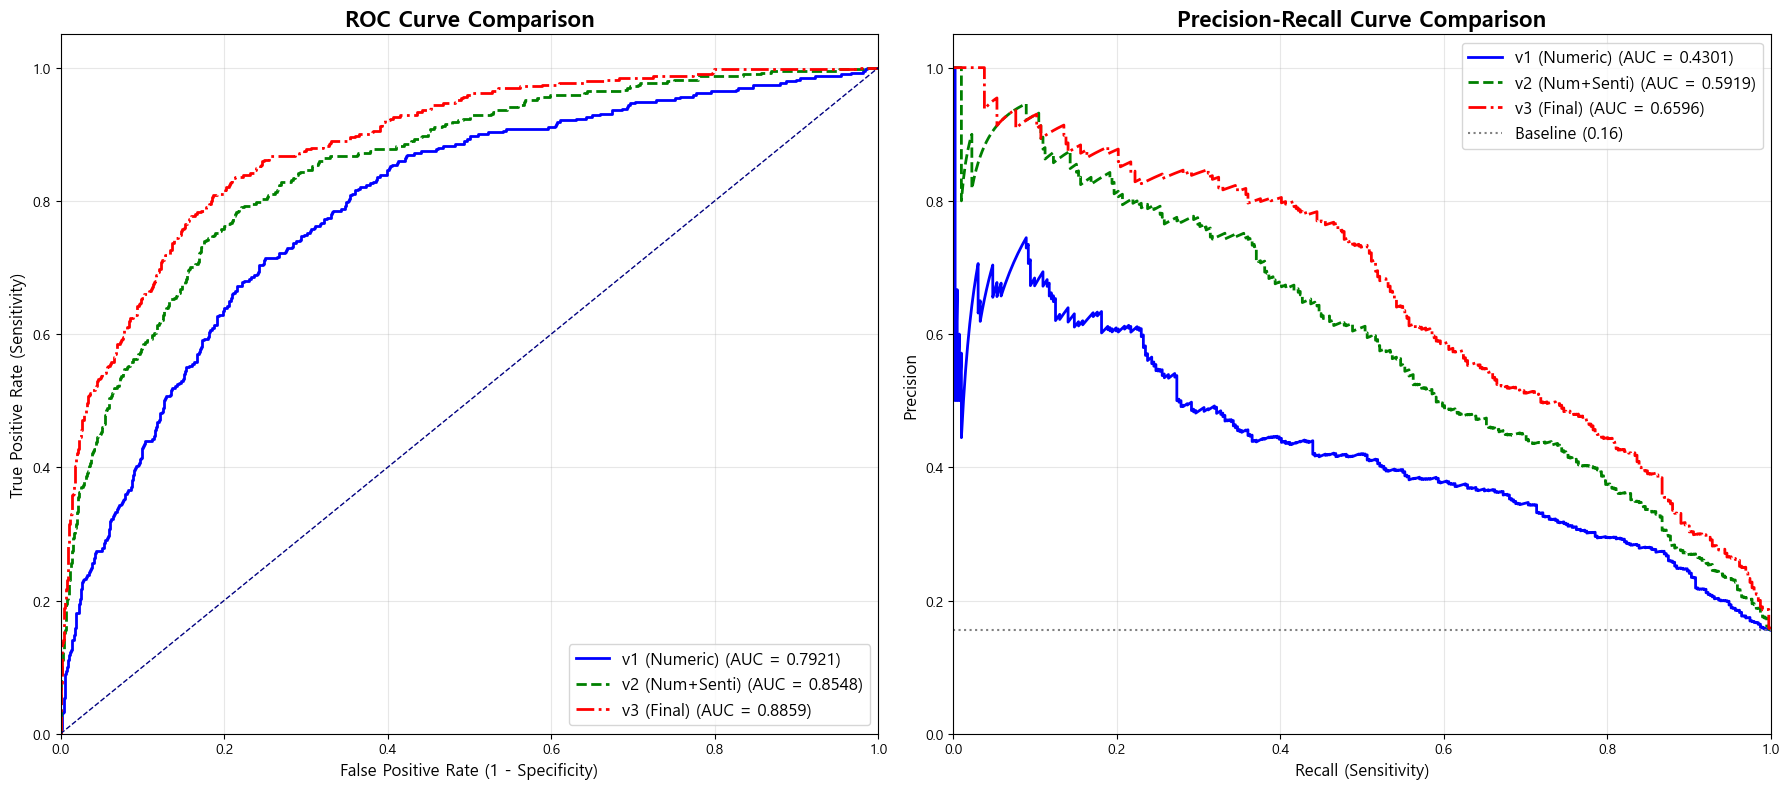

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import platform

# ============================================================================
# 1. 설정 및 공통 함수 정의
# ============================================================================

# 폰트 설정
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# 공통 하이퍼파라미터 (로그에 기록된 값 사용)
COMMON_PARAMS = {
    'learning_rate': 0.04903894565756329,
    'max_depth': 9,
    'min_child_weight': 1,
    'subsample': 0.9348616543304641,
    'colsample_bytree': 0.650685543824143,
    'gamma': 2.608448013178697e-08,
    'reg_alpha': 7.63793088472451e-08,
    'reg_lambda': 1.890270722333748e-08,
    'n_estimators': 449,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'random_state': 42,
}

def train_and_predict(file_name, version_label):
    """
    데이터 파일을 읽어 모델을 학습하고 2024년 Test셋에 대한 예측 확률과 실제값을 반환합니다.
    """
    print(f"[{version_label}] 데이터 로드 중: {file_name}")
    try:
        df = pd.read_csv(file_name, encoding='utf-8-sig')
    except FileNotFoundError:
        print(f"⚠️ 파일을 찾을 수 없습니다: {file_name}")
        return None, None

    # 전처리
    df_model = df[~df['corp_code'].isna()].copy()
    
    # Time-based Split
    df_train = df_model[df_model['bsns_year'] <= 2023].copy()
    df_test = df_model[df_model['bsns_year'] >= 2024].copy()

    # 피처 준비
    exclude_cols = [
        'stock_code', 'corp_code', 'bsns_year', 'target_year',
        'Company_Name', 'company_name', 'Status', 'Target', 'y'
    ]
    feature_cols = [col for col in df_model.columns if col not in exclude_cols]
    
    X_train = df_train[feature_cols].copy()
    y_train = df_train['Target'].copy()
    X_test = df_test[feature_cols].copy()
    y_test = df_test['Target'].copy()

    # Inf 처리
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    # scale_pos_weight 계산
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    params = COMMON_PARAMS.copy()
    params['scale_pos_weight'] = scale_pos_weight

    # 모델 학습
    print(f"[{version_label}] 학습 중...")
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)
    
    # 예측
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    return y_test, y_pred_proba

# ============================================================================
# 2. 모델 실행 및 데이터 수집
# ============================================================================

results = {}

# 버전별 파일명 리스트 (실제 파일명과 경로가 맞는지 확인 필요)
versions = [
    ('v1 (Numeric)', 'data_v1_numeric.csv'),
    ('v2 (Num+Senti)', 'data_v2_numeric_sentiment.csv'),
    ('v3 (Final)', '최종_통합데이터_모델링용.csv') # v3 파일명
]

for label, fname in versions:
    y_true, y_score = train_and_predict(fname, label)
    if y_true is not None:
        results[label] = (y_true, y_score)

# ============================================================================
# 3. 시각화 (ROC-AUC & PR-AUC Overlay)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors = ['blue', 'green', 'red']
line_styles = ['-', '--', '-.']

# --- ROC Curve ---
for (label, (y_true, y_score)), color, ls in zip(results.items(), colors, line_styles):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, linestyle=ls, 
                 label=f'{label} (AUC = {roc_auc:.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curve Comparison', fontsize=16, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=12)
axes[0].grid(True, alpha=0.3)

# --- PR Curve ---
for (label, (y_true, y_score)), color, ls in zip(results.items(), colors, line_styles):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    axes[1].plot(recall, precision, color=color, lw=2, linestyle=ls, 
                 label=f'{label} (AUC = {pr_auc:.4f})')

# No Skill Line (Baseline) - v3 기준으로 계산 (Test셋 비율은 비슷할 것이므로)
if 'v3 (Final)' in results:
    y_test_v3 = results['v3 (Final)'][0]
    no_skill = len(y_test_v3[y_test_v3==1]) / len(y_test_v3)
    axes[1].plot([0, 1], [no_skill, no_skill], linestyle=':', color='gray', label=f'Baseline ({no_skill:.2f})')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=16, fontweight='bold')
axes[1].legend(loc="upper right", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()